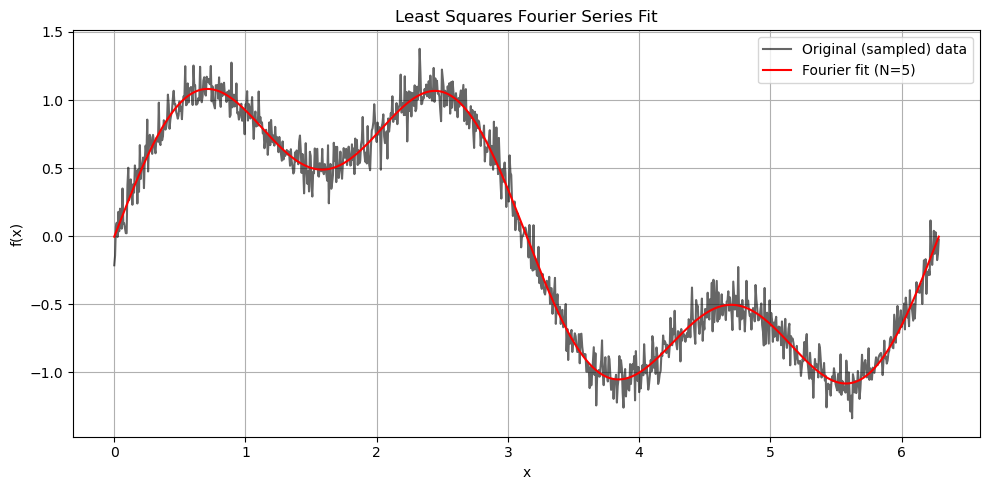

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import lstsq

# Sampled data (example: sine + noise)
T = 2 * np.pi                     # period
N = 5                             # number of harmonics
num_points = 1000
x = np.linspace(0, T, num_points)
y = np.sin(x) + 0.5 * np.sin(3 * x) + 0.1 * np.random.randn(num_points)

# Design matrix
X = np.ones((num_points, 2 * N + 1))
omega = 2 * np.pi / T

for n in range(1, N + 1):
    X[:, 2 * n - 1] = np.cos(n * omega * x)
    X[:, 2 * n] = np.sin(n * omega * x)

# Solve least squares: X @ c ≈ y
coeffs, _, _, _ = lstsq(X, y, rcond=None)

# Evaluate fitted Fourier series
y_fit = X @ coeffs

# Plot
plt.figure(figsize=(10, 5))
plt.plot(x, y, 'k-', alpha=0.6, label='Original (sampled) data')
plt.plot(x, y_fit, 'r-', label=f'Fourier fit (N={N})')
plt.title("Least Squares Fourier Series Fit")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [2]:
a0 = coeffs[0]
an = coeffs[1::2]  # aₙ
bn = coeffs[2::2]  # bₙ

In [3]:
print(a0)
print(an)
print(bn)

-5.292917331827902e-05
[-0.00350123  0.0031321  -0.00047674 -0.00385444  0.00159143]
[ 0.99474707  0.01266078  0.49647589 -0.0046638  -0.00182982]
